In [28]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%run main.py


--- Computing greenfield on full 2D grid ---
  Max wall deflection      : 9.33 mm
  Wall volume loss VLW     : 0.1157 m²
  Surface/wall vol ratio   : 0.878
  Integration check ratio  : 0.9999  (should be ~1)

--- Computing greenfield at building line ---

--- Greenfield strain analysis ---
  Max angular distortion   : 0.1542 ‰
  Max horizontal strain    : 0.0052 %
  Max tensile strain (GF)  : 0.0079 %

--- Running Timoshenko SSI model ---
  Max tensile strain (SSI) : 0.0001 %
  Damage category (SSI)    : 0  (0=negligible → 5=very severe)

========== SUMMARY ==========
  Wall deflection shape    : 5  (0=Uniform,1=Cantilever,2=Parabola,3=Composite,4=Kick-in,5=Custom)
  Avg wall displacement    : 0.027 % of Hwall
  Max wall deflection      : 9.33 mm
  GF  max tensile strain   : 0.0079 %
  SSI max tensile strain   : 0.0001 %
  Damage category (SSI)    : 0


<Figure size 640x480 with 0 Axes>

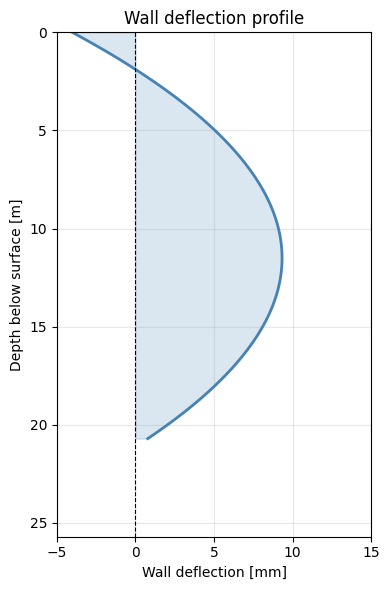

In [36]:
fig, ax = plt.subplots(figsize=(4, 6))
ax.plot(wall_deflection_profile * 1000, depth_vec, 'steelblue', lw=2)
ax.fill_betweenx(depth_vec, 0, wall_deflection_profile * 1000, alpha=0.2, color='steelblue')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlim(left=-5, right=15)
ax.set_ylim([retaining_wall_depth+5, 0])   # surface at top
ax.set_xlabel('Wall deflection [mm]')
ax.set_ylabel('Depth below surface [m]')
ax.set_title('Wall deflection profile')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


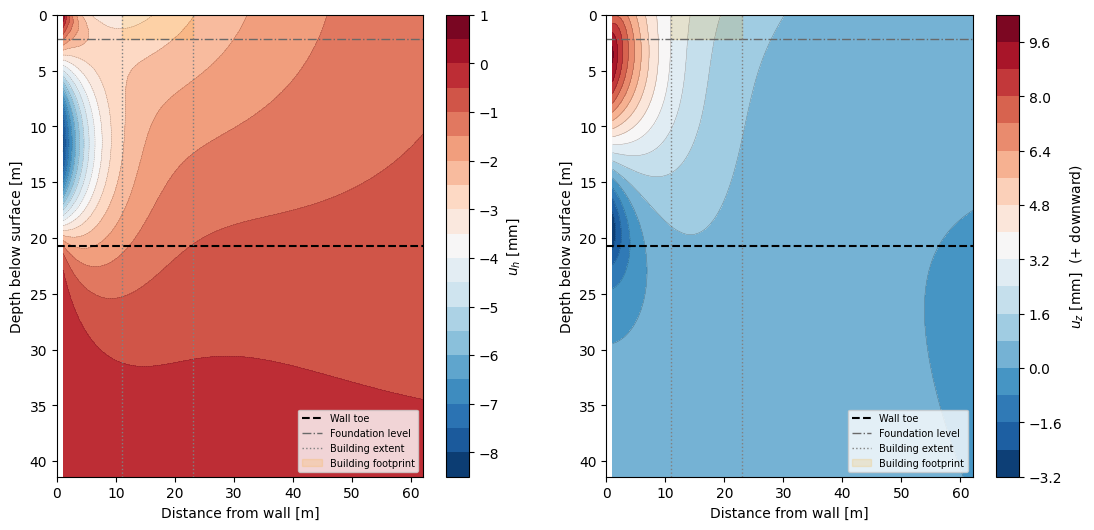

In [30]:
#x_lim = [x_grid[0], x_grid[-1]]   # [m] x-axis limits
#z_lim = [z_grid[-1], 0]            # [m] y-axis limits (inverted: surface at top)

x_lim = [0, 3 * retaining_wall_depth]
z_lim = [2 * retaining_wall_depth, 0]


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
levels = 20

for ax, data, label in zip(
        axes,
        [uh_grid * 1000, uz_grid * 1000],
        ['$u_h$ [mm]', '$u_z$ [mm]  (+ downward)']):

    cf = ax.contourf(x_grid, z_grid, data, levels=levels, cmap='RdBu_r')
    ax.contour(x_grid, z_grid, data, levels=levels,
               colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(cf, ax=ax, label=label)

    ax.axhline(retaining_wall_depth, color='k',      lw=1.5, ls='--', label='Wall toe')
    ax.axhline(foundation_depth,     color='dimgray', lw=1.0, ls='-.', label='Foundation level')
    ax.axvline(building_offset,                color='gray', lw=1.0, ls=':')
    ax.axvline(building_offset + building_length, color='gray', lw=1.0, ls=':',
               label='Building extent')
    ax.add_patch(Rectangle((building_offset, 0), building_length, foundation_depth,
                            alpha=0.15, color='orange', label='Building footprint'))

    ax.set_xlim(x_lim)
    ax.set_ylim(z_lim)
    ax.set_xlabel('Distance from wall [m]')
    ax.set_ylabel('Depth below surface [m]')
    ax.legend(fontsize=7, loc='lower right')



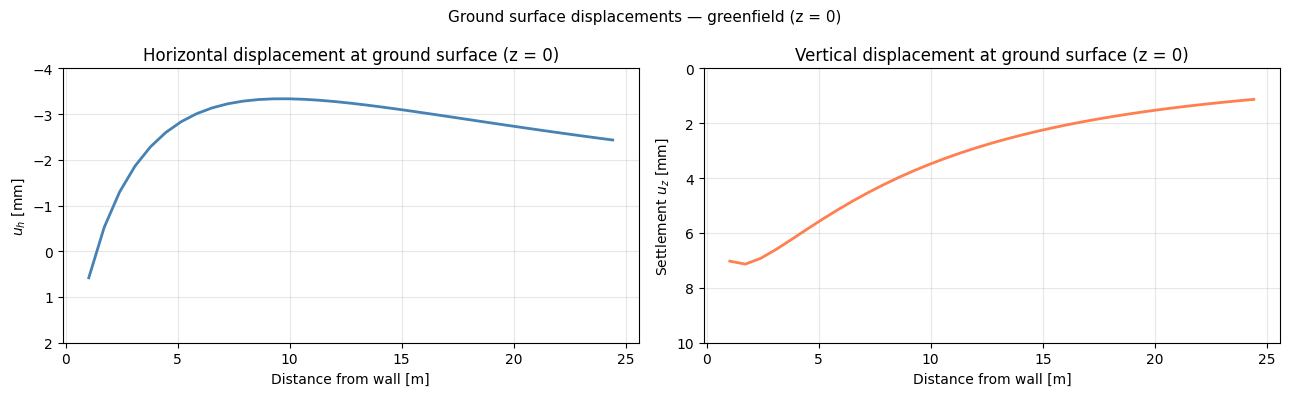

In [31]:
x_max_surface = 25.0   # [m] adjust as needed

#z_grid[0] = 0 exactly, so row 0 of the grid is the ground surface
mask = x_grid <= x_max_surface

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_grid[mask], uh_grid[0, mask] * 1000, 'steelblue', lw=2)
axes[0].invert_yaxis()
axes[0].set_xlabel('Distance from wall [m]')
axes[0].set_ylabel('$u_h$ [mm]')
axes[0].set_title('Horizontal displacement at ground surface (z = 0)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(2, -4)  # e.g. axes[0].set_ylim(-5, 5)

axes[1].plot(x_grid[mask], uz_grid[0, mask] * 1000, 'coral', lw=2)
axes[1].invert_yaxis()
axes[1].set_xlabel('Distance from wall [m]')
axes[1].set_ylabel('Settlement $u_z$ [mm]')
axes[1].set_title('Vertical displacement at ground surface (z = 0)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(10, 0)  # e.g. axes[1].set_ylim(-5, 5)

plt.suptitle('Ground surface displacements — greenfield (z = 0)', fontsize=11)
plt.tight_layout()
plt.show()


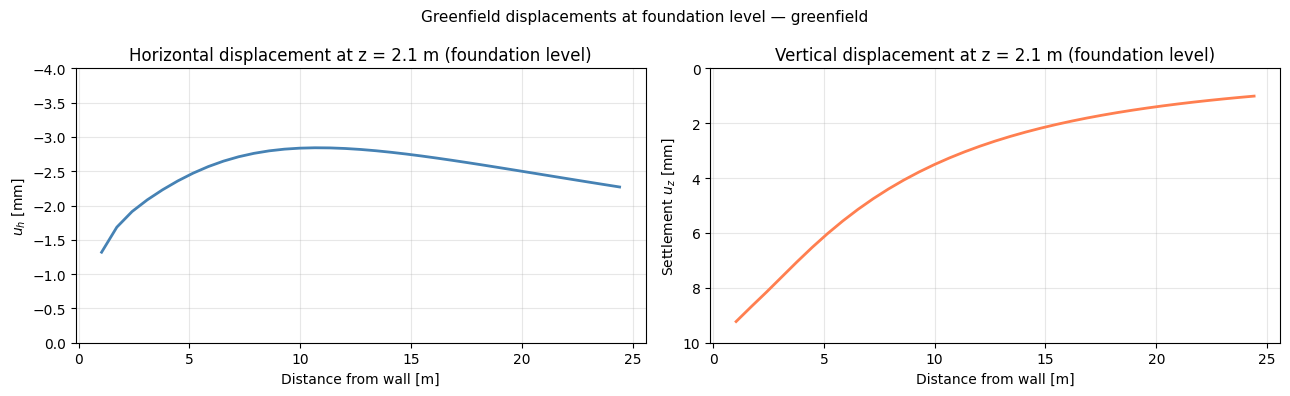

In [38]:
x_max_surface = 25.0
mask = x_grid <= x_max_surface

# Find the grid row closest to foundation depth
idx_foundation = np.argmin(np.abs(z_grid - foundation_depth))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_grid[mask], uh_grid[idx_foundation, mask] * 1000, 'steelblue', lw=2)
axes[0].set_xlabel('Distance from wall [m]')
axes[0].set_ylabel('$u_h$ [mm]')
axes[0].set_title(f'Horizontal displacement at z = {z_grid[idx_foundation]:.1f} m (foundation level)')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, -4)

axes[1].plot(x_grid[mask], uz_grid[idx_foundation, mask] * 1000, 'coral', lw=2)
axes[1].invert_yaxis()
axes[1].set_xlabel('Distance from wall [m]')
axes[1].set_ylabel('Settlement $u_z$ [mm]')
axes[1].set_title(f'Vertical displacement at z = {z_grid[idx_foundation]:.1f} m (foundation level)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(10, 0)

plt.suptitle(f'Greenfield displacements at foundation level — greenfield', fontsize=11)
plt.tight_layout()
plt.show()


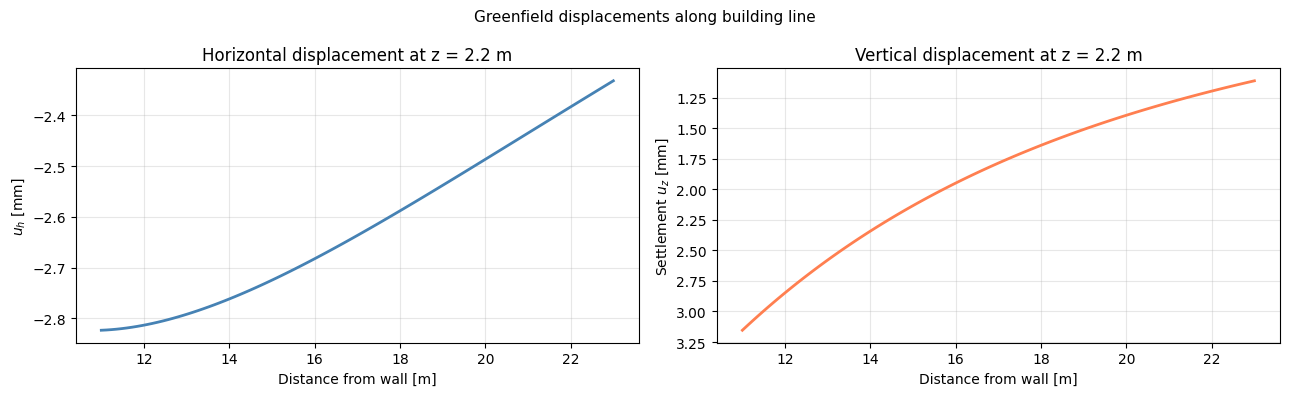

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_coords_building, Sx * 1000, 'steelblue', lw=2)
axes[0].set_xlabel('Distance from wall [m]')
axes[0].set_ylabel('$u_h$ [mm]')
axes[0].set_title(f'Horizontal displacement at z = {foundation_depth:.1f} m')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_coords_building, Sz * 1000, 'coral', lw=2)
axes[1].invert_yaxis()
axes[1].set_xlabel('Distance from wall [m]')
axes[1].set_ylabel('Settlement $u_z$ [mm]')
axes[1].set_title(f'Vertical displacement at z = {foundation_depth:.1f} m')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Greenfield displacements along building line', fontsize=11)
plt.tight_layout()
plt.show()


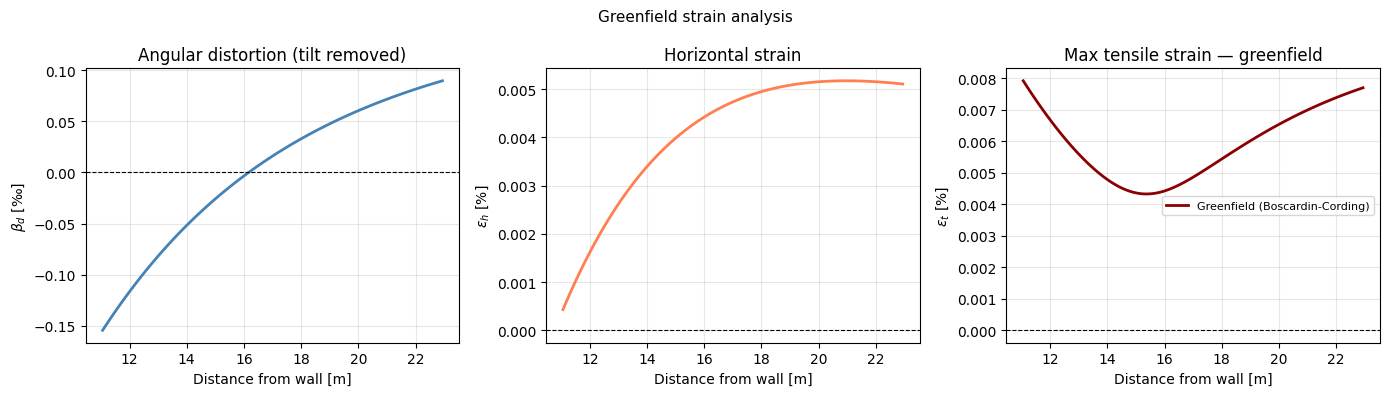

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_elem_centres, beta_d * 1000, 'steelblue', lw=2)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('Distance from wall [m]')
axes[0].set_ylabel('$\\beta_d$ [‰]')
axes[0].set_title('Angular distortion (tilt removed)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_elem_centres, eps_h * 100, 'coral', lw=2)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('Distance from wall [m]')
axes[1].set_ylabel('$\\varepsilon_h$ [%]')
axes[1].set_title('Horizontal strain')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_elem_centres, eps_t_gf * 100, 'darkred', lw=2,
             label='Greenfield (Boscardin-Cording)')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_xlabel('Distance from wall [m]')
axes[2].set_ylabel('$\\varepsilon_t$ [%]')
axes[2].set_title('Max tensile strain — greenfield')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Greenfield strain analysis', fontsize=11)
plt.tight_layout()
plt.show()


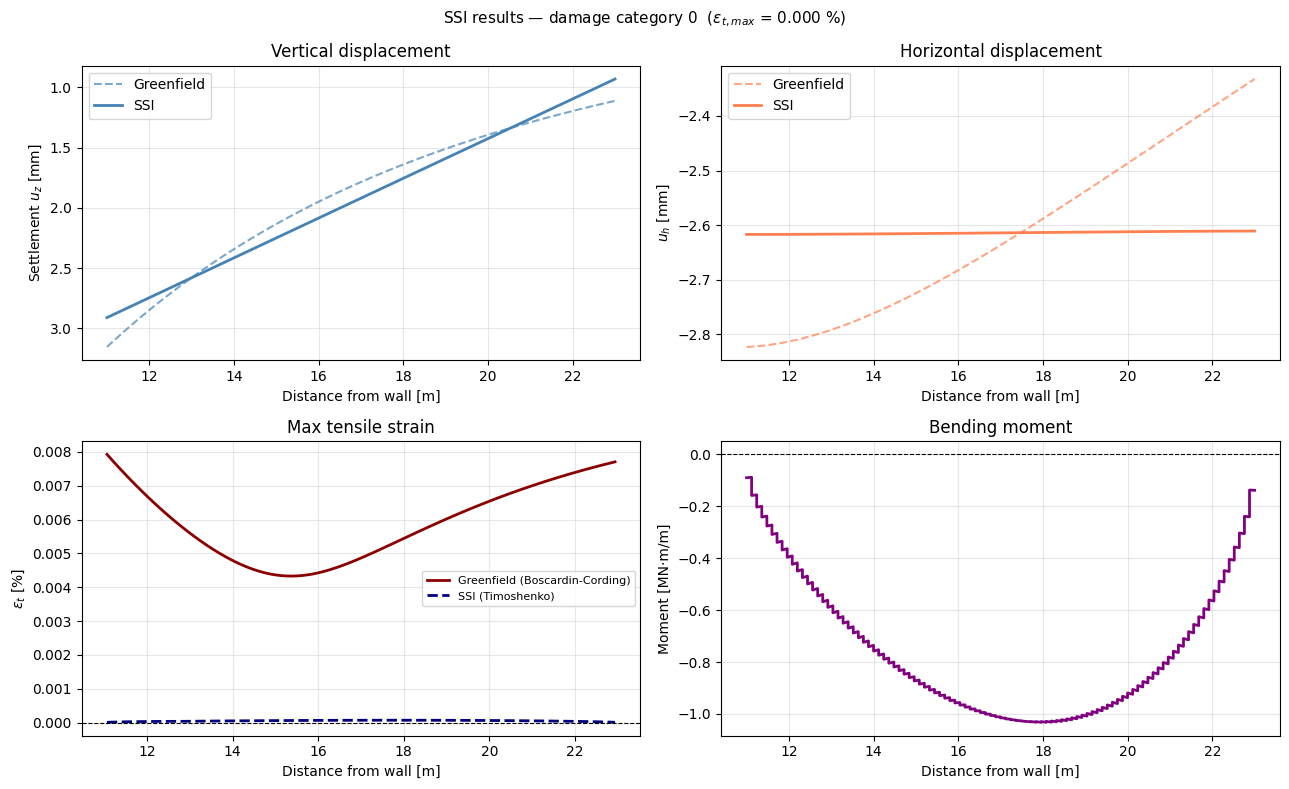

In [34]:
# x-coordinates at element ends for strain/force plots (2 values per element)
x_strain = np.zeros(2 * num_elements)
x_strain[0::2] = x_coords_building[:-1]
x_strain[1::2] = x_coords_building[1:]

# SSI tensile strain averaged to element centres (matches x_elem_centres)
eps_t_ssi_elem = 0.5 * (model.eps_t[0::2] + model.eps_t[1::2])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Vertical displacement — note: model.beam_DispV is FEM convention (upward +), negate to compare with Sz
ax = axes[0, 0]
ax.plot(x_coords_building, Sz * 1000,               'steelblue', lw=1.5, ls='--', alpha=0.7, label='Greenfield')
ax.plot(x_coords_building, -model.beam_DispV * 1000, 'steelblue', lw=2,             label='SSI')
ax.invert_yaxis()
ax.set_xlabel('Distance from wall [m]')
ax.set_ylabel('Settlement $u_z$ [mm]')
ax.set_title('Vertical displacement')
ax.legend()
ax.grid(True, alpha=0.3)

# Horizontal displacement
ax = axes[0, 1]
ax.plot(x_coords_building, Sx * 1000,              'coral', lw=1.5, ls='--', alpha=0.7, label='Greenfield')
ax.plot(x_coords_building, model.beam_DispL * 1000, 'coral', lw=2,             label='SSI')
ax.set_xlabel('Distance from wall [m]')
ax.set_ylabel('$u_h$ [mm]')
ax.set_title('Horizontal displacement')
ax.legend()
ax.grid(True, alpha=0.3)

# Tensile strain comparison
ax = axes[1, 0]
ax.plot(x_elem_centres, eps_t_gf * 100,    'darkred', lw=2,       label='Greenfield (Boscardin-Cording)')
ax.plot(x_elem_centres, eps_t_ssi_elem * 100, 'navy', lw=2, ls='--', label='SSI (Timoshenko)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Distance from wall [m]')
ax.set_ylabel('$\\varepsilon_t$ [%]')
ax.set_title('Max tensile strain')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Bending moment
ax = axes[1, 1]
ax.plot(x_strain, model.moment / 1e6, 'purple', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Distance from wall [m]')
ax.set_ylabel('Moment [MN·m/m]')
ax.set_title('Bending moment')
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'SSI results — damage category {damage_category}  '
    f'($\\varepsilon_{{t,max}}$ = {max_eps_t_ssi:.3f} %)',
    fontsize=11)
plt.tight_layout()
plt.show()
